In [1]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor

from sklearn.datasets import load_iris

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys

# =====================================


### **L2 Regularization: Ridge Regression**

1. L2 regularization, or ridge regression, is a regularization method that penalizes high-value 
   coefficients in a machine learning model.

2. Can't perform feature selection:
   L2 regularization can reduce coefficient values toward zero but never exactly to zero. This 
   also means that L2 regularization cannot perform feature selection. 

3. Cost Functions:
   
   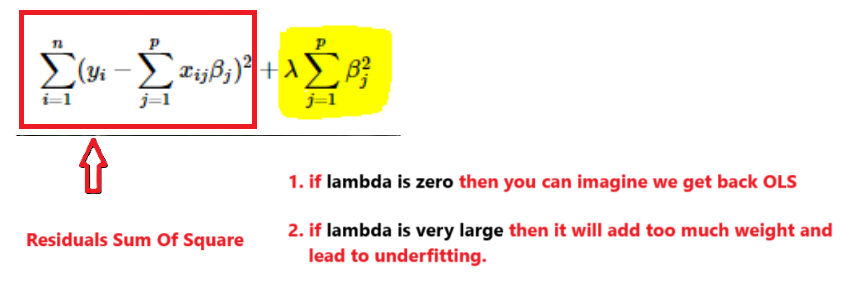

4. L2 regularization can effectively handle multicollinearity in a data set. 

#### Difference between L1 and L2 regularization techniques 
lasso regression shrinks the less important feature’s coefficient to zero, removing some features altogether. In other words, L1 regularization works well for feature selection in case we have a huge number of features.

Where L2 regularization make cofficient close to zero. So L2 regularization not deal with feature scalling. However L2 regularization greate deal with multicolinearity.

In another word L1 not good work with multicolinearity, but better deal with feature selection.

#### L2 regularization works by:

1. Adding a penalty term: The penalty term is added to the loss function to discourage large weights.
2. Reducing overfitting: By penalizing large weights, L2 regularization reduces overfitting and encourages the model to learn more generalizable features.
3. Improving generalization: L2 regularization improves the generalization of the model by reducing the impact of noisy or irrelevant features.

#### Advantages of L2 Regularization

1. Reduces overfitting: L2 regularization reduces overfitting by penalizing large weights.
2. Improves generalization: L2 regularization improves the generalization of the model by reducing the impact of noisy or irrelevant features.
3. Easy to implement: L2 regularization is easy to implement and can be added to most machine learning algorithms.

#### Disadvantages of L2 Regularization

1. Can lead to underfitting: If the regularization strength is too high, L2 regularization can lead to underfitting.
2. Can be sensitive to feature scaling: L2 regularization can be sensitive to feature scaling, and features with large ranges can dominate the regularization term.




#### Data Set

In [44]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)
df = pd.DataFrame({'inx':np.ravel(X),'out':np.ravel(y)})


In [55]:
ridge_reg = Ridge(alpha=0.1, solver="auto")
rdg = ridge_reg.fit(X, y)
rdg.intercept_,rdg.coef_

(array([0.97898394]), array([[0.3828496]]))

In [54]:
Xcns = sm.add_constant(X)
mod = sm.OLS(y,Xcns)
res = mod.fit_regularized(method='elastic_net',alpha=(0.1/2,0.1), L1_wt=1.0)
print('almost equivalent to Ridge: ',res.params)


almost equivalent to Ridge:  [0.97890878 0.34649056]


### L2 Regulariations by book method - Not Matched

In [60]:
alfa = 0.1
XdasX = np.dot(np.transpose(Xcns),Xcns)
ridge_coff_ = np.dot(np.linalg.inv((XdasX + np.identity(XdasX.shape[1])*alfa)),np.dot(np.transpose(Xcns),y))
ridge_coff_


array([[0.96302187],
       [0.39096765]])